In [2]:
import pandas as pd
import numpy as np
import spacy
import emoji
import nltk
import re
from nltk.corpus import stopwords
from spacy.lang.es.stop_words import STOP_WORDS
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Cargar el dataset

In [3]:
file_path = "../notebooks/data/sentiment_analysis_dataset.csv"
df = pd.read_csv(file_path)

# Definir hiperparámetros

In [4]:
MAX_VOCAB_SIZE = 10000  # Número máximo de palabras en el vocabulario
MAX_SEQUENCE_LENGTH = 50  # Longitud máxima de las secuencias de texto
EMBEDDING_DIM = 100  # Dimensión de los vectores de embedding

# Limpiar el texto

In [5]:
nltk.download('stopwords')
nltk.download('punkt')

# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_sm")

# Definir stopwords en español
stop_words = set(stopwords.words('spanish')) | STOP_WORDS

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\WilmarAl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\WilmarAl\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
def preprocess_text(text):
    text = emoji.replace_emoji(text, replace='')
    text = text.lower()
    text = text.replace('á','a').replace('é','e')
    text = text.replace('í','i').replace('ó','o')
    text = text.replace('ú','u').replace('$','')
    text = text.replace('—','').replace('-',' ')
    text = text.replace('%','').replace('&','')
    text = text.replace('\n',' ').replace('\t',' ')
    text = text.replace("'","").replace('"','')
    text = text.replace(',','').replace('.','')
    text = text.replace(';','').replace(':','')
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Eliminar menciones
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)  # Eliminar hashtags
    text = re.sub(r'http\S+|www\.\S+', '', text)  # Eliminar URLs
    text = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ ]', '', text)  # Eliminar caracteres especiales y emojis
    return text

    #doc = nlp(text)
    
    # Eliminar stopwords y lematizar
    #palabras_procesadas = [token.lemma_ for token in doc if token.text.lower() not in stop_words and not token.is_punct]
    
    #return " ".join(palabras_procesadas)

In [7]:
df['text'] = df['text'].apply(preprocess_text)
df.head()

,user,text,date,emotion,sentiment
0,@erreborda,termine bien abrumado despues de hoy,"Jan 6, 2024 · 2:53 AM UTC",overwhelmed,scared
1,@shpiderduck,me siento abrumado,"Jan 6, 2024 · 2:35 AM UTC",overwhelmed,scared
2,@Alex_R_art,me siento un poco abrumado por la cantidad de ...,"Jan 6, 2024 · 12:20 AM UTC",overwhelmed,scared
3,@anggelinaa97,salvador la unica persona que no la ha abrumad...,"Jan 5, 2024 · 10:38 PM UTC",overwhelmed,scared
4,@diegoreyesvqz,denme un helado o algo que ando full abrumado,"Jan 5, 2024 · 8:38 PM UTC",overwhelmed,scared


# Tokenización del texto

In [8]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text"])

# Convertir texto a secuencias numéricas

In [9]:
X_sequences = tokenizer.texts_to_sequences(df["text"])
X_padded = pad_sequences(X_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Traducción de las etiquetas

In [10]:
translation = {
    'joyful': 'Alegre',
    'daring': 'Osado',
    'optimistic': 'Optimista',
    'playful': 'Jugueton',
    'powerful': 'Poderoso',
    'surprised': 'Sorprendido',
    'successful': 'Exitoso',
    'confident': 'Confiado',
    'peaceful': 'Tranquilo',
    'secure': 'Seguro',
    'thankful': 'Agradecido',
    'loving': 'Amoroso',
    'relaxed': 'Relajado',
    'responsive': 'Sensible',
    'sad': 'Triste',
    'sleepy': 'Adormilado',
    'isolated': 'Aislado',
    'stupid': 'Estupido',
    'mad': 'Histerico',
    'distant': 'Distante',
    'frustrated': 'Frustrado',
    'irritated': 'Irritado',
    'jealous': 'Celoso',
    'scared': 'Asustado',
    'embarrassed': 'Avergonzado',
    'overwhelmed': 'Agobiado',
}

df[['emotion', 'sentiment']] = df[['emotion', 'sentiment']].replace(to_replace = translation)
df.head()

,user,text,date,emotion,sentiment
0,@erreborda,termine bien abrumado despues de hoy,"Jan 6, 2024 · 2:53 AM UTC",Agobiado,Asustado
1,@shpiderduck,me siento abrumado,"Jan 6, 2024 · 2:35 AM UTC",Agobiado,Asustado
2,@Alex_R_art,me siento un poco abrumado por la cantidad de ...,"Jan 6, 2024 · 12:20 AM UTC",Agobiado,Asustado
3,@anggelinaa97,salvador la unica persona que no la ha abrumad...,"Jan 5, 2024 · 10:38 PM UTC",Agobiado,Asustado
4,@diegoreyesvqz,denme un helado o algo que ando full abrumado,"Jan 5, 2024 · 8:38 PM UTC",Agobiado,Asustado


# Codificación de etiquetas (emociones)

In [11]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["emotion"])
n_classes = len(label_encoder.classes_)

# Dividir en conjunto de entrenamiento y prueba

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42)

# Cargar Embeddings Preentrenados (GloVe)

In [13]:
embeddings_index = {}
with open("../notebooks/conf/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Crear matriz de embedding

In [14]:
word_index = tokenizer.word_index
num_words = min(MAX_VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
for word, i in word_index.items():
    if i < MAX_VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# Construcción de la red CNN para clasificación de texto

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, 
                              output_dim=EMBEDDING_DIM, 
                              weights=[embedding_matrix], 
                              input_length=MAX_SEQUENCE_LENGTH, 
                              trainable=False),  # Se pueden congelar o ajustar
    tf.keras.layers.Conv1D(filters=256, kernel_size=5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(n_classes, activation='softmax')
])

# Compilar el modelo

In [16]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo y guardar el historial

In [17]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


65/65 [==============================] - 2s 17ms/step - loss: 3.0096 - accuracy: 0.0613 - val_loss: 2.9996 - val_accuracy: 0.0502
Epoch 2/20
65/65 [==============================] - 1s 12ms/step - loss: 2.9846 - accuracy: 0.0714 - val_loss: 2.9892 - val_accuracy: 0.0444
Epoch 3/20
65/65 [==============================] - 1s 11ms/step - loss: 2.9563 - accuracy: 0.0835 - val_loss: 3.0015 - val_accuracy: 0.0598
Epoch 4/20
65/65 [==============================] - 1s 11ms/step - loss: 2.9144 - accuracy: 0.1071 - val_loss: 2.9761 - val_accuracy: 0.0734
Epoch 5/20
65/65 [==============================] - 1s 11ms/step - loss: 2.8399 - accuracy: 0.1347 - val_loss: 2.9840 - val_accuracy: 0.0772
Epoch 6/20
65/65 [==============================] - 1s 11ms/step - loss: 2.7288 - accuracy: 0.1762 - val_loss: 3.0017 - val_accuracy: 0.0811
Epoch 7/20
65/65 [==============================] - 1s 11ms/step - loss: 2.5797 - accuracy: 0.2080 - val_loss: 3.0148 - val_accuracy: 0.1042
Epoch 8/20


# Evaluar el modelo

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {100*test_acc:.2f}%")

17/17 [==============================] - 0s 5ms/step - loss: 4.1706 - accuracy: 0.1178
Test Accuracy: 11.78%


# Graficar accuracy y val_accuracy

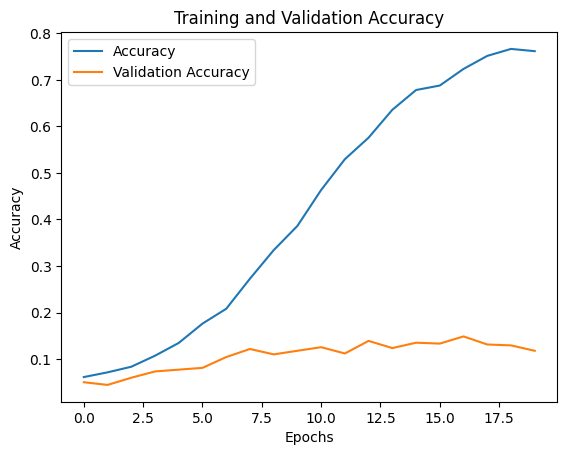

In [19]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()